### Do an nhom
### Mon hoc: Nhap mon khoa hoc du lieu 

### Pha phan tich

In [1]:
!pip install pandas numpy matplotlib seaborn networkx scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings

import networkx as nx  
from matplotlib.lines import Line2D


# Config
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
try:
    df = pd.read_json('manga_data_cleaned.json')
    print(f"File load thanh cong. Kich thuoc {df.shape[0]} dong, {df.shape[1]} cot.")
except ValueError as e:
    print(f"Loi doc file: f{e}")

# Quick check
display(df.head(3))
display(df.info())

File load thanh cong. Kich thuoc 52433 dong, 21 cot.


,mal_id,url,title,title_english,status,type,chapters,volumes,score,scored_by,...,popularity,members,favorites,synopsis,genres,themes,demographics,authors,main_picture,start_year
0,1,https://myanimelist.net/manga/1/Monster,Monster,Monster,Finished,Manga,162,18,9.16,113775.0,...,27,282893,23393,"Kenzou Tenma, a renowned Japanese neurosurgeon...","[Award Winning, Drama, Mystery]","[Adult Cast, Psychological]",[Seinen],"[Urasawa, Naoki]",https://cdn.myanimelist.net/images/manga/3/258...,1994.0
1,2,https://myanimelist.net/manga/2/Berserk,Berserk,Berserk,Publishing,Manga,0,0,9.47,390037.0,...,1,779855,136463,"Guts, a former mercenary now known as the Blac...","[Action, Adventure, Award Winning, Drama, Fant...","[Gore, Military, Psychological]",[Seinen],"[Miura, Kentarou, Studio Gaga]",https://cdn.myanimelist.net/images/manga/1/157...,1989.0
2,3,https://myanimelist.net/manga/3/20th_Century_Boys,20th Century Boys,20th Century Boys,Finished,Manga,249,22,8.93,106718.0,...,24,303414,22624,"As the 20th century approaches its end, people...","[Award Winning, Drama, Mystery, Sci-Fi]","[Historical, Psychological]",[Seinen],"[Urasawa, Naoki]",https://cdn.myanimelist.net/images/manga/5/260...,1999.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52433 entries, 0 to 52432
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mal_id         52433 non-null  int64  
 1   url            52433 non-null  object 
 2   title          52433 non-null  object 
 3   title_english  18867 non-null  object 
 4   status         52433 non-null  object 
 5   type           52433 non-null  object 
 6   chapters       52433 non-null  int64  
 7   volumes        52433 non-null  int64  
 8   score          52433 non-null  float64
 9   scored_by      20258 non-null  float64
 10  rank           52433 non-null  int64  
 11  popularity     52433 non-null  int64  
 12  members        52433 non-null  int64  
 13  favorites      52433 non-null  int64  
 14  synopsis       52433 non-null  object 
 15  genres         52433 non-null  object 
 16  themes         52433 non-null  object 
 17  demographics   52433 non-null  object 
 18  author

None

### Xu ly du lieu

In [3]:
# Feature Engineering 

# 1. Create genres_str for RAG Metadata (list to string)
df['genres_str'] = df['genres'].apply(lambda x: ', '.join(x) if isinstance(x, list) else '')

# 2. Create search_text for RAG Metadata: Title + genres + synopsis
df['search_text'] = df['title'] + " " + df['genres_str'] + " " + df['synopsis']

# 3. Instead of all zero-filters, we use weighted score to judge 
# a: average score of voted mangas
# m: minimum voting threshold

a = df[df['score'] > 0]['score'].mean()
print(f"Average voted score: {a:.2f}")
m = df[df['members'] > 0]['members'].quantile(0.5) 
print(f"Minimum voting threshold: {m:.0f}")

def weighted_rating(x, m=m, a=a):
    v = x['members']
    R = x['score']
    # If x not voted, consider score = average score
    if R == 0: R = a 
    return (v/(v+m) * R) + (m/(v+m) * a)
    
df['final_score'] = df.apply(weighted_rating, axis=1)

# 4. Calculate popularity_score: 
# Log Transform 
df['members_log'] = np.log1p(df['members'])
df['favorites_log'] = np.log1p(df['favorites'])

# Min-Max Normalization 
scaler = MinMaxScaler()
df[['members_scaled', 'favorites_scaled']] = scaler.fit_transform(df[['members_log', 'favorites_log']])

# Popularity = 70% Members + 30% Favorites
df['popularity_score'] = 0.6 * df['members_scaled'] + 0.4 * df['favorites_scaled']

Average voted score: 6.97
Minimum voting threshold: 228


### Thong ke ket qua

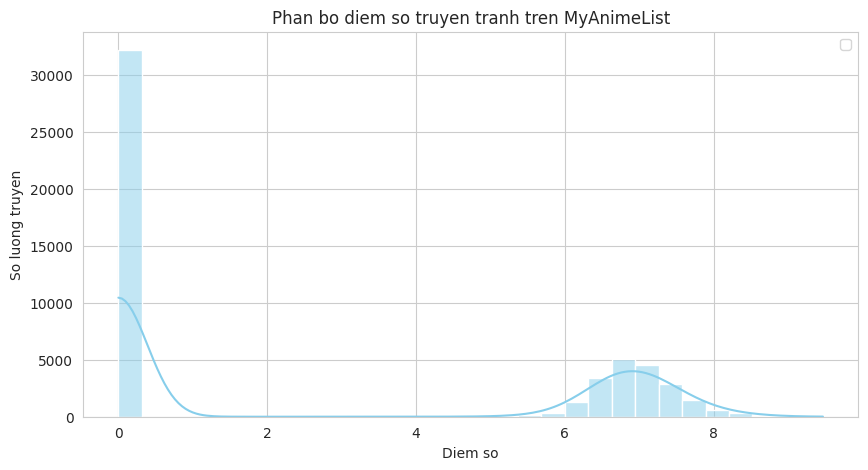

In [4]:
# Raw Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['score'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Phan bo diem so truyen tranh tren MyAnimeList')
plt.xlabel('Diem so')
plt.ylabel('So luong truyen')
# plt.axvline(df['score'].mean(), color='red', linestyle='--', label=f'Trung binh: {df["score"].mean():.2f}')
plt.legend()
plt.show()

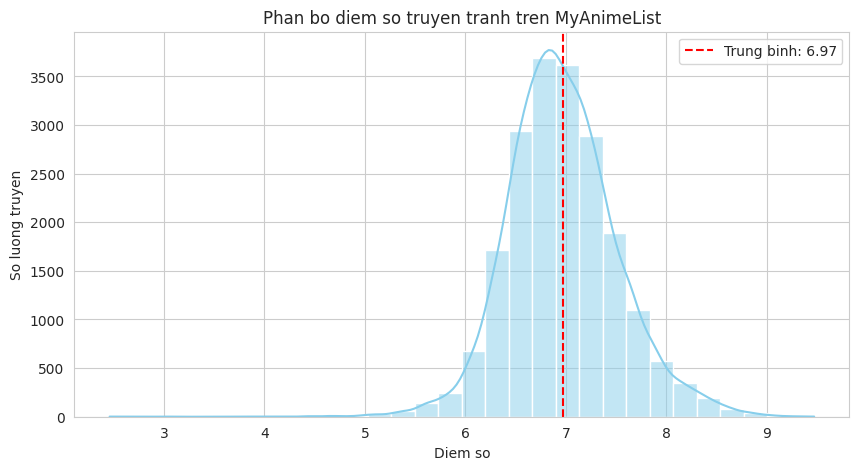

In [5]:
# Actual Score Distribution (without zeros)
df_rated = df[df['score'] > 0].copy()

plt.figure(figsize=(10, 5))
sns.histplot(df_rated['score'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Phan bo diem so truyen tranh tren MyAnimeList')
plt.xlabel('Diem so')
plt.ylabel('So luong truyen')
plt.axvline(df_rated['score'].mean(), color='red', linestyle='--', label=f'Trung binh: {df_rated["score"].mean():.2f}')
plt.legend()
plt.show()

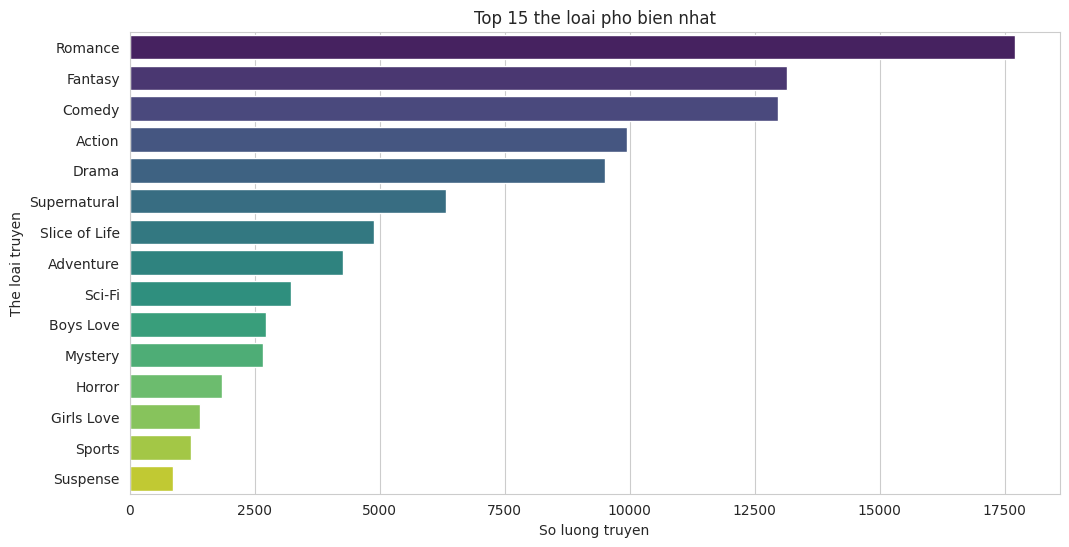

In [6]:
# Top 15 most popular genres
all_genres = [genre for genres in df['genres'] if isinstance(genres, list) for genre in genres]
top_genres = pd.Series(all_genres).value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 15 the loai pho bien nhat')
plt.xlabel('So luong truyen')
plt.ylabel('The loai truyen')
plt.show()

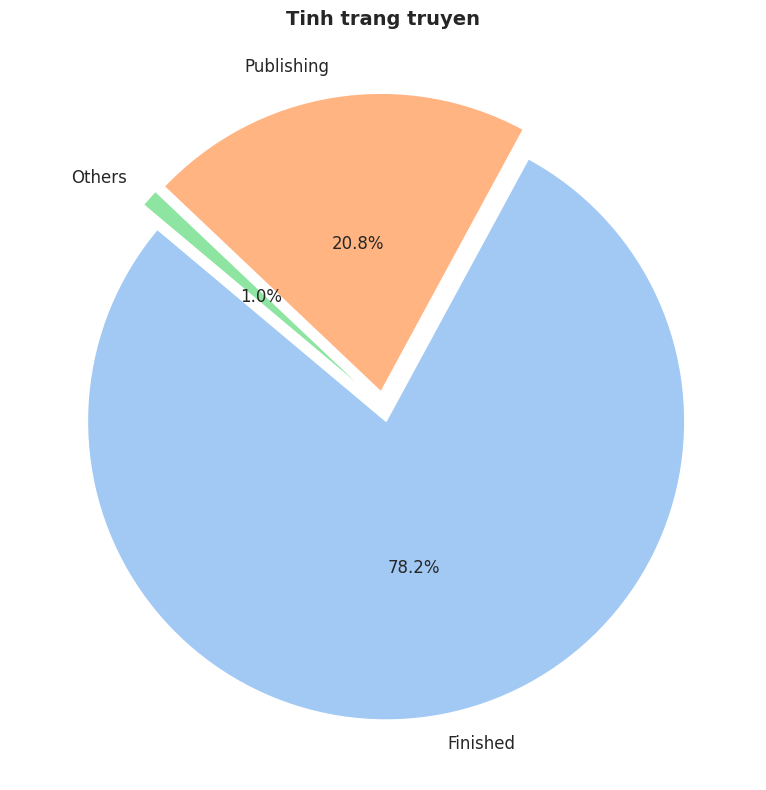

In [7]:
# Publishing status
status_counts = df['status'].value_counts()

# The status mostly contains 'Publishing' and 'Finished' status, which leaves a small number of 'On Hiatus' and 'Discontinued' status.
# The minority (< 2%) will share the name as 'Others'

threshold = 0.02
total = status_counts.sum()
mask = status_counts / total < threshold

# Split slides 
large_slices = status_counts[~mask]
small_slices = status_counts[mask]

# Merge small slices as 'Others'
plot_data = large_slices.copy()
if not small_slices.empty:
    plot_data['Others'] = small_slices.sum()

# Draw
plt.figure(figsize=(8, 8))
explode = [0.05] * len(plot_data) 
colors = sns.color_palette('pastel')[0:len(plot_data)]

plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode, pctdistance=0.5, textprops={'fontsize': 12})


plt.title('Tinh trang truyen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

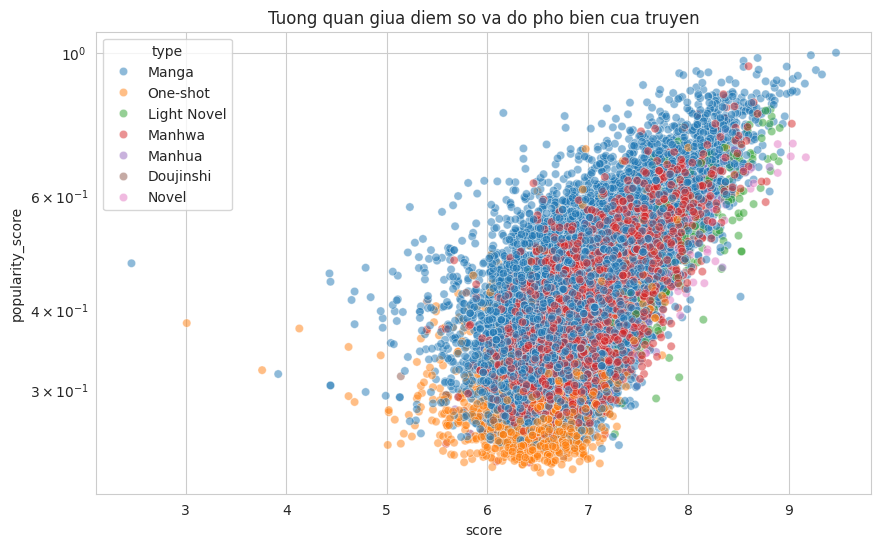

In [8]:
# Scatter plot: Score vs Popularity, using log scale
df_rated = df[df['score'] > 0].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rated, x='score', y='popularity_score', alpha=0.5, hue='type')
plt.yscale('log')
plt.title('Tuong quan giua diem so va do pho bien cua truyen')
plt.show()

In [10]:
top_manga = df.sort_values(by='popularity_score', ascending=False).head(60).copy()
G = nx.Graph()

# Coloring
COLOR_MANGA = '#75bfec'   # Sky blue
COLOR_GENRE = '#ffff00'   # Yellow
COLOR_AUTHOR = '#ff0000'  # Red

# 2. Node and edge creation (using top_manga)
for idx, row in top_manga.iterrows():
    manga_node = row['title'] # Simplified name for better label visibility
    G.add_node(manga_node, node_type='manga', size= 2000, color=COLOR_MANGA)
    
    if isinstance(row['genre'], list):
        for genre in row['genre']:
            G.add_node(genre, node_type='genre', size=1000, color=COLOR_GENRE)
            G.add_edge(manga_name, genre, relation='belongs_to_genre', weight=1)
            
    if isinstance(row['authors'], list):
        for author in row['authors']:
            auth_name = author['name'] if isinstance(author, dict) else str(author)
            
            # Get shorten names (first name only)
            short_auth = auth_name.split(',')[0] 
            G.add_node(short_auth, type='Author', size=1000, color=COLOR_AUTHOR)
            G.add_edge(manga_name, short_auth, relation='written_by', weight=2)

# Community Detection
communities = community.greedy_modularity_communities(G)

# Label communities for each node
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

# Visualization
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, k=0.6, iterations=60, seed=42)

# Manga (Circle)
nx.draw_networkx_nodes(G, pos, 
                       nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'Manga'],
                       node_color=COLOR_MANGA, node_size=1200, node_shape='o', alpha=0.9, label='Manga')

# Genre (Square)
nx.draw_networkx_nodes(G, pos, 
                       nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'Genre'],
                       node_color=COLOR_GENRE, node_size=800, node_shape='s', alpha=0.8, label='Genre')

# Author (Triangle)
nx.draw_networkx_nodes(G, pos, 
                       nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'Author'],
                       node_color=COLOR_AUTHOR, node_size=800, node_shape='^', alpha=0.8, label='Author')

# Edges
# Manga-Genre (Solid line)
genre_edges = [(u, v) for u, v, d in G.edges(data=True) if d['relation'] == 'belongs_to_genre']
nx.draw_networkx_edges(G, pos, edgelist=genre_edges, width=1.0, edge_color='#bdc3c7', style='solid')

# Manga-Author (Dashed line)
author_edges = [(u, v) for u, v, d in G.edges(data=True) if d['relation'] == 'written_by']
nx.draw_networkx_edges(G, pos, edgelist=author_edges, width=1.5, edge_color='#7f8c8d', style='dashed')

# Labels
# Manga belongs to genre
labels = {n: n for n, d in G.nodes(data=True) if d['type'] in ['Manga', 'Genre', 'Author']}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_family='sans-serif', font_weight='bold')

# Legends
legend_elements = [
    mpatches.Patch(color=COLOR_MANGA, label='Manga (Node)'),
    mpatches.Patch(color=COLOR_GENRE, label='Genre (Node)'),
    mpatches.Patch(color=COLOR_AUTHOR, label='Author (Node)'),
    plt.Line2D([0], [0], color='#bdc3c7', lw=2, linestyle='solid', label='Relationship: Thuộc thể loại'),
    plt.Line2D([0], [0], color='#7f8c8d', lw=2, linestyle='dashed', label='Relationship: Được viết bởi')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title("Knowledge Graph: Manga - Genre - Author Relationships\n(Top 60 Popular Manga)", fontsize=20)
plt.axis('off') 
plt.tight_layout()
plt.show()

KeyError: 'Genre'

In [ ]:
# Hierarchical tree 

# Top 10 mangas with the most popularity
top_manga_tree = df.nlargest(10, 'popularity_score').copy()

G = nx.Graph()

# --- Level 0: Type (Specifically 'manga') ---
root_node = "Manga"
G.add_node(root_node, layer=0, label="Manga") 

# Create branches 
for _, row in top_manga_tree.iterrows():
    # Title, Genre
    title = row['title']
    genre = row['genres'][0] if isinstance(row['genres'], list) and row['genres'] else "Unknown Genre"
    
    # Author (First name only)
    author_raw = row['authors'][0] if isinstance(row['authors'], list) and row['authors'] else "Unknown Author"
    author_name = author_raw.split(',')[0] 

    # --- Nodes and edges ---

    # Level 1: Genre
    genres_list = row['genres'] if isinstance(row['genres'], list) else []
    if not genres_list:
        genres_list = ["Unknown Genre"]
        
    for genre in genres_list:
        if not G.has_node(genre):
            G.add_node(genre, layer=1, label=genre)
        G.add_edge(root_node, genre)
    
        # Level 2: Author
        # Create author_id for each genre-author group
        author_id = f"{genre}_{author_name}" 
        
        if not G.has_node(author_id):
            G.add_node(author_id, layer=2, label=author_name) 
        G.add_edge(genre, author_id) 
    
        # Level 3: Title 
        if not G.has_node(title):
            G.add_node(title, layer=3, label=title)
        G.add_edge(author_id, title)

# Draw
pos = nx.multipartite_layout(G, subset_key="layer")
plt.figure(figsize=(18, 12))
color_map = []

for node in G.nodes():
    layer = G.nodes[node]['layer']
    if layer == 0:   color_map.append('#008000') # Level 0: Green (Root)
    elif layer == 1: color_map.append('#ffff00') # Level 1: Yellow (Genre)
    elif layer == 2: color_map.append('#ff0000') # Level 2: Red (Author)
    else:            color_map.append('#75bfec') # Level 3: Light blue (Title)

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=2500, alpha=0.9, edgecolors='white')
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.4, arrows=True, arrowsize=15, connectionstyle='arc3,rad=0.05')
labels = nx.get_node_attributes(G, 'label')
font_sizes = {node: 12 if G.nodes[node]['layer'] < 3 else 9 for node in G.nodes()}
for node, (x, y) in pos.items():
    plt.text(x, y, labels[node], fontsize=font_sizes[node], ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.title('Mo hinh cay phan cap 4 tang: Manga -> Genre -> Author -> Title', fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
final_cols = [
    'mal_id', 'title', 'synopsis', 'genres_str', 'score', 
    'status', 'url', 'main_picture', 'popularity_score', 'search_text'
]
# Filter
existing_cols = [c for c in final_cols if c in df.columns]
df_final = df[existing_cols]

output_file = 'processed_manga.pkl'
df_final.to_pickle(output_file)